This is a machine learning model to predict the class of tumors using the breast cancer dataset. The algorithm adopted for this model building is the logistic regression.

In [212]:
# importing the required modules

import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, f1_score, classification_report, precision_score
from sklearn.preprocessing import LabelEncoder
# import modules for visualization
import matplotlib.pyplot as plt 
import seaborn as sns
from IPython.display import clear_output 
import time
import os
import warnings
warnings.filterwarnings('ignore')


In [144]:
# loading the breast cancer dataset

tumor_df = pd.read_csv('breast-cancer.csv')

In [145]:
# view the first five instances of the dataframe
tumor_df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [146]:
# verify the structural pattern of the dataset

tumor_df.shape

(569, 32)

This dataset has 569 records and 32 features

In [147]:
#  check the information on the data

tumor_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

The data is such that it has 30 float64 features, 1 object data type and 1 int64

In [148]:
# view the statistical structure of the data
tumor_df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [149]:
tumor_df.describe(include='all')

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,3.037183e+07,NaN,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,NaN,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,NaN,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,NaN,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,NaN,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,NaN,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080


Data Cleaning

In [150]:
# check for null or missing value

null_value = tumor_df.isnull().sum()
print(null_value)

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


None of the rows contained any null values


In [151]:
# check for duplicate rows

duplicate_rows = tumor_df[tumor_df.duplicated()]
print(len(duplicate_rows)) # count and sum the numbers of duplicate rows

0


No duplicate rows as well

Exploratory Data Analysis

In [152]:
# use a more readable encoding for the target variable

tumor_df['diagnosis'] = tumor_df['diagnosis'].replace({'M': 'Malignant', 'B': 'Benign'})

In [153]:
# determine the value count for the diagnosis(target variable)
tumor_df['diagnosis'].value_counts()

diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

There are 357 Benign classes and 212 Malignant

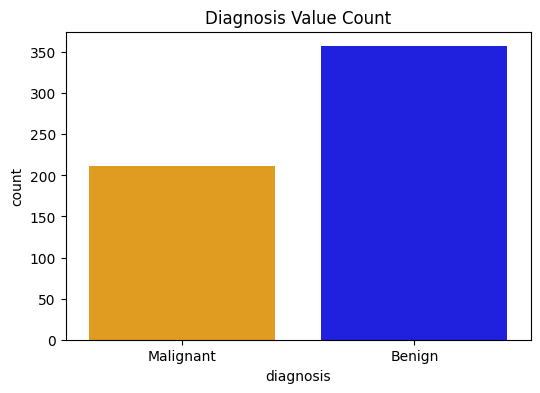

In [154]:
# plotting the target distribution

plt.figure(figsize=(6, 4))
plt.title('Diagnosis Value Count')
sns.countplot(data=tumor_df, x='diagnosis', palette=['orange', 'blue'])
plt.show()

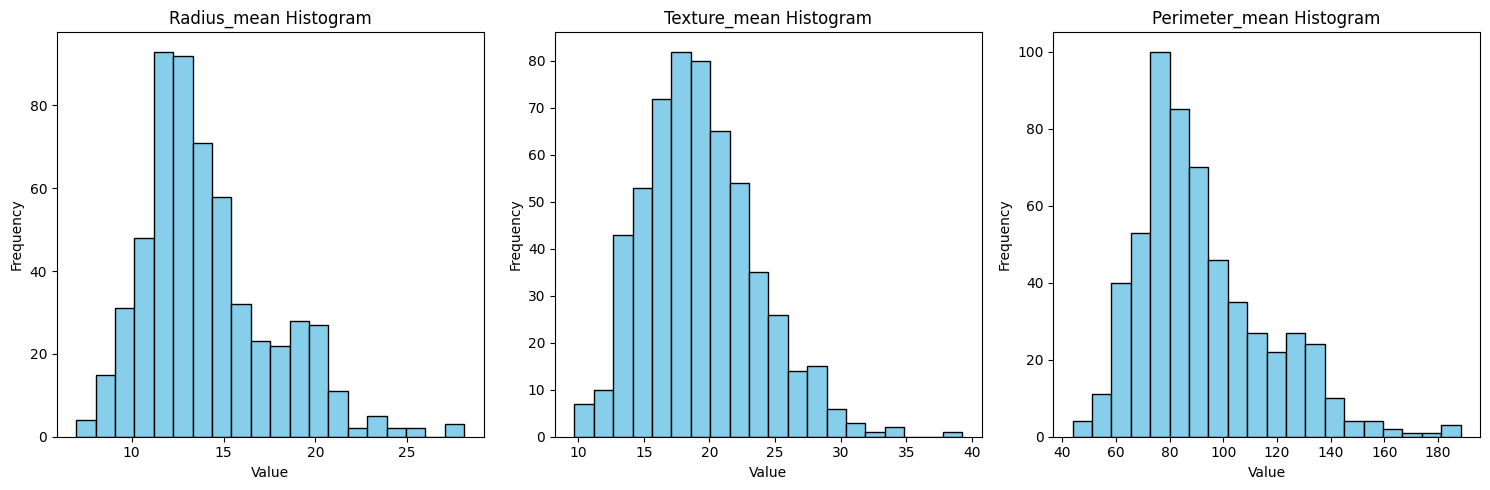

In [155]:
# compare mean feature

# List of features to plot
mean_features = ['radius_mean', 'texture_mean', 'perimeter_mean']

# Set up subplots
fig, axes = plt.subplots(nrows=1, ncols=len(mean_features), figsize=(15, 5))

# Plot histograms for each feature
for i, j in enumerate(mean_features):
    axes[i].hist(tumor_df[j], bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(j.capitalize() + ' Histogram')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()


Data Preprocessing

In [156]:
# view the column lists

tumor_df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [157]:
# drop columns that will not be needed for the analysis

irrelevalnt_columns = ['id', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se']
tumor_df = tumor_df.drop(columns=irrelevalnt_columns) 

In [158]:
# view the resulting dataframe

tumor_df.head()

,diagnosis,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,Malignant,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,Malignant,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,Malignant,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,Malignant,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,Malignant,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [159]:
# use label encoder to encode the diagnosis input
le = LabelEncoder() # an object of the label encoder

# apply the labe encoder to the diagnosis column
tumor_df['diagnosis'] = le.fit_transform(tumor_df['diagnosis'])

In [160]:
# divide the dataset into features and target

X = tumor_df.drop(columns='diagnosis')
y = tumor_df['diagnosis']

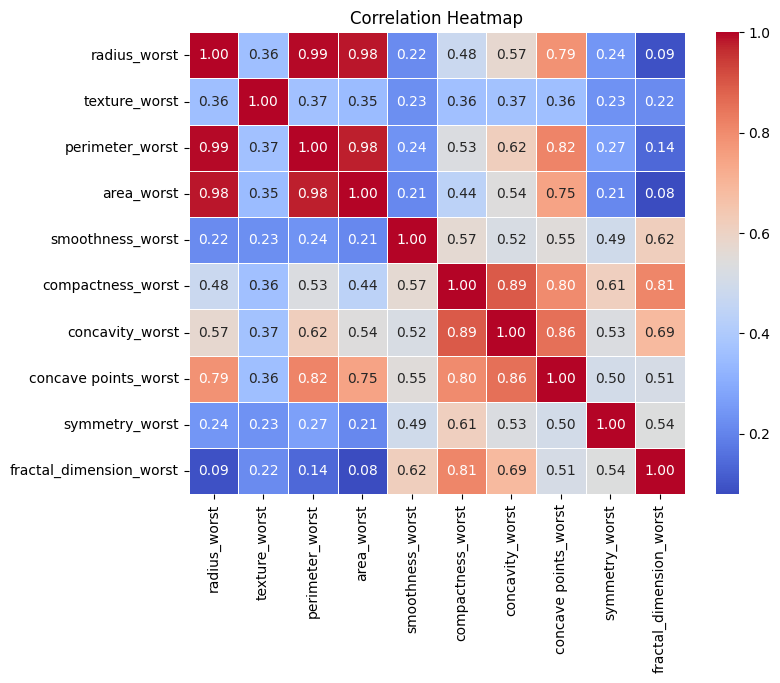

In [161]:
# correlation matrix plot

# object of the correlation matrix
corr = X.corr()

# plot the correlation heatmap

plt.figure(figsize=(8, 6))
plt.title('Correlation Heatmap')
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.show()

In [162]:
# split the labels and feature into train and test set

X_train, X_test,  y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Model Training

In [163]:
# Build and train a prediction model using logistic regression algorithm

lgr = LogisticRegression()



In [164]:
# train the model
model = lgr.fit(X_train, y_train)
model

LogisticRegression()

In [165]:
# form a prediction set for the model

y_pred = model.predict(X_test)

In [166]:
# check the prediction

y_pred

array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0])

Evaluation

In [167]:
# accuracy score

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.9707602339181286


In [168]:
# precision score
precision = precision_score(y_test, y_pred, average='weighted')
print(precision)

0.9711000474158369


In [169]:
# confusion matrix

conf = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n")
print(conf)

Confusion Matrix:

[[107   1]
 [  4  59]]


In [170]:
# obtain the classification report

report = classification_report(y_test, y_pred)

print("---"*30)
print('Classification Report')
print("---"*30)
print(report)

------------------------------------------------------------------------------------------
Classification Report
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       108
           1       0.98      0.94      0.96        63

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



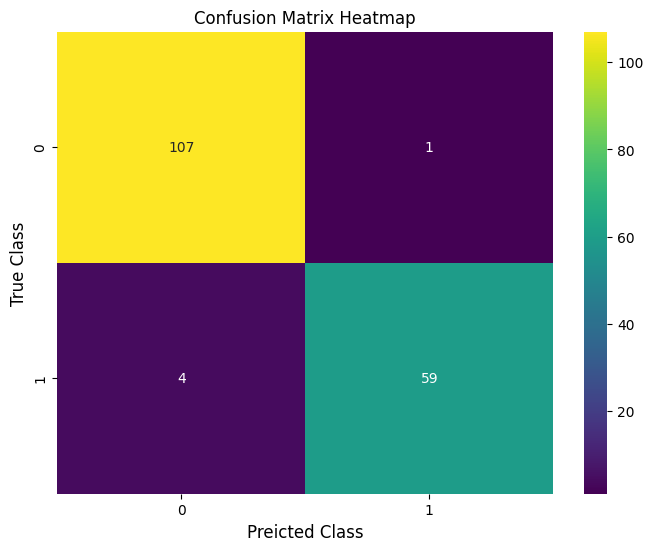

In [171]:
# plot the confusion matrix heatmap

plt.figure(figsize=(8, 6))
ax= sns.heatmap(conf, annot=True, cmap='viridis', fmt='d')
plt.title("Confusion Matrix Heatmap", fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.xlabel('Preicted Class', fontsize=12)

plt.show()


Inference for the model

In [172]:
# check the structure of the test set

X_test.shape

(171, 10)

In [173]:
# view first five rows of the test label dataset
y_test.head()

204    0
70     1
131    1
431    0
540    0
Name: diagnosis, dtype: int32

In [174]:
# view the first test features dataset
X_test.head()

,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
204,14.97,24.64,96.05,677.9,0.1426,0.2378,0.2671,0.10150,0.3014,0.08750
70,24.86,26.58,165.90,1866.0,0.1193,0.2336,0.2687,0.17890,0.2551,0.06589
131,19.26,26.00,124.90,1156.0,0.1546,0.2394,0.3791,0.15140,0.2837,0.08019
431,12.88,22.91,89.61,515.8,0.1450,0.2629,0.2403,0.07370,0.2556,0.09359
540,12.26,19.68,78.78,457.8,0.1345,0.2118,0.1797,0.06918,0.2329,0.08134


The test dataset has 171 records that are new to the trained model, few of these will be used to check the predictions of the breast cancer diagnosis

In [175]:
# rename concave points_worst column

rename_column = {'concave points_worst': 'concave_points_worst'}

X_test.rename(columns=rename_column, inplace=True)


In [176]:
X_test.columns

Index(['radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
       'smoothness_worst', 'compactness_worst', 'concavity_worst',
       'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [216]:


# function to clear error message for an incomplete or wrong input
def display_and_clear_error_message(message, duration_seconds=5):
    # Display the error message
   
    print(f"{message}")

    # Wait for the specified duration
    time.sleep(duration_seconds)

    # Clear the console screen (works on Windows, Linux, and macOS)
    os.system('cls' if os.name == 'nt' else 'clear')



# function to clear output after displaying the error message

def clear_output_after_execution():
    clear_output(wait=True)




# create function to use the model in predicting breast cancer

def predict_breast_cancer():
    try:
       # get the features for making the predictions
       
       get_radius_worst = float(input("Enter the radius worst:"))
       get_texture_worst = float(input("Enter the texture worst"))
       get_perimeter_worst = float(input('Enter the perimeter worst'))
       get_area_worst =float(input("Enter the area worst"))
       get_smoothness_worst = float(input("Enter smoothness worst"))
       get_compactness_worst = float(input("Enter compactness worst"))
       get_concavity_worst = float(input("Enter concavity worst"))
       get_concave_point_worst = float(input("Enter concave point worst"))
       get_symmetry_worst = float(input("Enter symmetry worst"))
       get_fractal_dimension_worst = float(input("Enter fractal dimension worst"))
    
      # features column
       feat_col = ['radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
       'smoothness_worst', 'compactness_worst', 'concavity_worst',
       'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']

       diag_inputs = [get_radius_worst, get_texture_worst, get_perimeter_worst, get_area_worst, 
                       get_smoothness_worst, get_compactness_worst,
                         get_concavity_worst, get_concave_point_worst, get_symmetry_worst, 
                         get_fractal_dimension_worst]
    
    # if statement to make predictions

       if (model.predict([[get_radius_worst, get_texture_worst, get_perimeter_worst, get_area_worst, 
                       get_smoothness_worst, get_compactness_worst,
                         get_concavity_worst, get_concave_point_worst, get_symmetry_worst, 
                         get_fractal_dimension_worst]])) == 0:
        
          print("The inputs for this breast cancer analysis:-")        
          for i, j in zip(feat_col, diag_inputs):
            
            print(f"{i}: {j}")
          print('\n')
          print("***"*30)
          print("Breast Cancer Diagnosis Prediction")
          print("***"*30) 
          print("This breast cancer is diagnosed to be MALIGNANT")
       else:
          print("The inputs for this breast cancer analysis:-")  
          for i, j in zip(feat_col, diag_inputs):
            
            print(f"{i}: {j}")
          print('\n')
          print("Breast Cancer Diagnosis Prediction")
          print("***"*30)
          print("This breast cancer is diagnosed to be BENIGN") 
          print("***"*30) 
          
       print("---end of diagnosis---")
    except ValueError:
      error_message = 'The input execution was aborted!'
      display_and_clear_error_message(error_message)
      clear_output
      clear_output_after_execution()
 

In [218]:
predict_breast_cancer()

The inputs for this breast cancer analysis:-
radius_worst: 19.26
texture_worst: 26.0
perimeter_worst: 124.9
area_worst: 1156.0
smoothness_worst: 0.1546
compactness_worst: 0.2394
concavity_worst: 0.3791
concave_points_worst: 0.1514
symmetry_worst: 0.2837
fractal_dimension_worst: 0.08019


Breast Cancer Diagnosis Prediction
******************************************************************************************
This breast cancer is diagnosed to be BENIGN
******************************************************************************************
---end of diagnosis---


The result of the prediction above is absolutely correct as seen from the row 131 of the X_test and y_test datasets. 